# SPARC vs DIII-D ESCAPE scan comparison

Compares the `nCX`/`nFC` free-parameter scans of the two machines at a single
`alpha_crit`. Assumes both `scan_SCfp_ESCAPE.py` scans have been run.

Each equilibrium is normalized by its own value at the reference point of the scan
(`ratio = 1`, `nFC(0) = 1e15`) before the equilibria of a machine are averaged, so
the two machines are compared on relative response instead of absolute pedestal
size.

In [1]:
# --- Cross-device ESCAPE scan comparison: loaders and configuration ---
# Reads the free-parameter scan outputs of both machines:
#   SPARC/SPARC_freeparam_loop_{nCX,nFC}/i{i}/          (one equilibrium, flat)
#   DIII-D/DIIIDSnyder_freeparam_loop_{nCX,nFC}/{equil}/i{i}/   (one dir per equilibrium)
# Each equilibrium is first normalized by its OWN value at the reference point of
# the scan; the machine's curve is then the mean of those normalized curves over
# every equilibrium found, with their standard deviation as the error bar. A run
# that failed (or has not finished) drops out of that point's average. SPARC has a
# single equilibrium, so its error bars are zero.

from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# ------------------------------------------------------------------ user input
ALPHA_CRIT = 0.01     # the alpha_crit family to compare across machines
# -----------------------------------------------------------------------------

# scan output directory per (device, scan)
SCAN_DIRS = {
    'SPARC': {
        'nCX': Path('SPARC/SPARC_freeparam_loop_nCX'),
        'nFC': Path('SPARC/SPARC_freeparam_loop_nFC'),
    },
    'DIII-D': {
        'nCX': Path('DIII-D/DIIIDSnyder_freeparam_loop_nCX'),
        'nFC': Path('DIII-D/DIIIDSnyder_freeparam_loop_nFC'),
    },
}

# per scan: which free parameter is on the x axis, how to label it, and the
# reference point every vertical axis is normalized by.
SCAN_SPEC = {
    'nCX': dict(key='ncx_x0_ratio',
                axis_label=r'$n_{\mathrm{CX}}(0)\,/\,n_{\mathrm{FC}}(0)$',
                title_label=r'$n_{CX}(0)/n_{FC}(0)$',
                logx=False,
                ref=1.0,
                ref_label=r'ratio $=1$'),
    'nFC': dict(key='nFC_x0',
                axis_label=r'$n_{\mathrm{FC}}(0)$ (m$^{-3}$)',
                title_label=r'$n_{FC}(0)$',
                logx=True,
                ref=1e15,
                ref_label=r'$n_{FC}(0)=10^{15}$ m$^{-3}$'),
}

DEVICE_COLORS = {'SPARC': 'tab:blue', 'DIII-D': 'tab:red'}
DEVICE_MARKERS = {'SPARC': 'o', 'DIII-D': '^'}


def _equil_dirs(scan_dir):
    """Equilibrium directories inside a scan output directory.

    SPARC keeps its run directories (i0, i1, ...) directly in the scan directory;
    DIII-D nests them one level deeper, one directory per equilibrium. Returns
    (tag, directory) pairs so both layouts read the same way.
    """
    scan_dir = Path(scan_dir)
    if any(scan_dir.glob('i*')):
        return [(scan_dir.name, scan_dir)]
    return [(p.name, p) for p in sorted(scan_dir.iterdir()) if p.is_dir()]


def load_runs(equil_dir, param_key, alpha_crit):
    """Finished runs of one equilibrium at one alpha_crit, sorted by param_key.

    Pedestal height is converted MPa -> kPa, matching the per-device notebooks.
    """
    # A failed run stores no free_params, so `failed`/`pending` cover every
    # alpha_crit in the scan, not just the requested one.
    runs, failed, pending = [], [], []
    for run_dir in sorted(Path(equil_dir).glob('i*'), key=lambda p: int(p.name[1:])):
        out_fp = run_dir / 'out_dict.npy'
        if not out_fp.exists():
            (failed if (run_dir / 'failed.npy').exists() else pending).append(run_dir.name)
            continue
        d = np.load(out_fp, allow_pickle=True).item()
        if not np.isclose(float(d['free_params']['alpha_crit']), alpha_crit):
            continue
        runs.append({
            'param':   float(d['free_params'][param_key]),
            'ped_h':   float(d['ESCAPE_ped_h']) * 1e3,        # MPa -> kPa
            'ped_wid': float(d['ESCAPE_ped_wid']),
        })
    runs.sort(key=lambda r: r['param'])
    return runs, failed, pending


def _reference(runs, ref_param, quantity):
    """`quantity` of the run sitting at the normalization point, or None."""
    for r in runs:
        if np.isclose(r['param'], ref_param, rtol=1e-6):
            return r[quantity]
    return None


def scan_points(scan_dir, param_key, alpha_crit, ref_param):
    """Mean and std over equilibria of ped_h / ped_wid, normalized per equilibrium.

    Every equilibrium is divided by its OWN value at ref_param BEFORE the average
    is taken, so each one contributes its relative response and the error bar is
    the spread in relative response rather than the spread in absolute pedestal
    size. An equilibrium with no converged run at ref_param cannot be normalized
    and is dropped.

    Returns (points, equils_used, raw_refs); raw_refs maps each equilibrium tag to
    its unnormalized reference values, kept only so the absolute scale of the
    normalization can be printed.
    """
    quantities = ('ped_h', 'ped_wid')
    per_point = {}
    equils_used = []
    raw_refs = {}
    for tag, equil_dir in _equil_dirs(scan_dir):
        runs, failed, pending = load_runs(equil_dir, param_key, alpha_crit)
        if not runs:
            print(f'    {tag}: no successful runs at alpha_crit={alpha_crit:g}, skipped')
            continue

        refs = {q: _reference(runs, ref_param, q) for q in quantities}
        if any(v is None for v in refs.values()):
            print(f'    {tag}: no converged run at the reference point '
                  f'{ref_param:g}, cannot normalize, skipped')
            continue

        equils_used.append(tag)
        raw_refs[tag] = refs
        print(f'    {tag}: successful {len(runs)} at this alpha_crit, '
              f'failed {len(failed)} / pending {len(pending)} over all alpha_crit')
        for r in runs:
            slot = per_point.setdefault(r['param'], {q: [] for q in quantities})
            for q in quantities:
                slot[q].append(r[q] / refs[q])   # normalize before averaging

    points = []
    for param, vals in sorted(per_point.items()):
        pt = {'param': param, 'n': len(vals['ped_h'])}
        for q, v in vals.items():
            v = np.asarray(v, dtype=float)
            pt[q] = float(v.mean())
            pt[q + '_std'] = float(v.std())   # population std over the equilibria
        points.append(pt)
    return points, equils_used, raw_refs

[nCX] alpha_crit = 0.01
  SPARC:
    SPARC_freeparam_loop_nCX: successful 10 at this alpha_crit, failed 2 / pending 0 over all alpha_crit
    10 scan points over 1 equilibria; unnormalized reference height [290.9] kPa, width [0.0328]
  DIII-D:
    125729.03589: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    125730.02445: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    125731.02893: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    125732.03508: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    125761.03760: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    125787.03894: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    128398.04295: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    128413.04088: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    128572.0

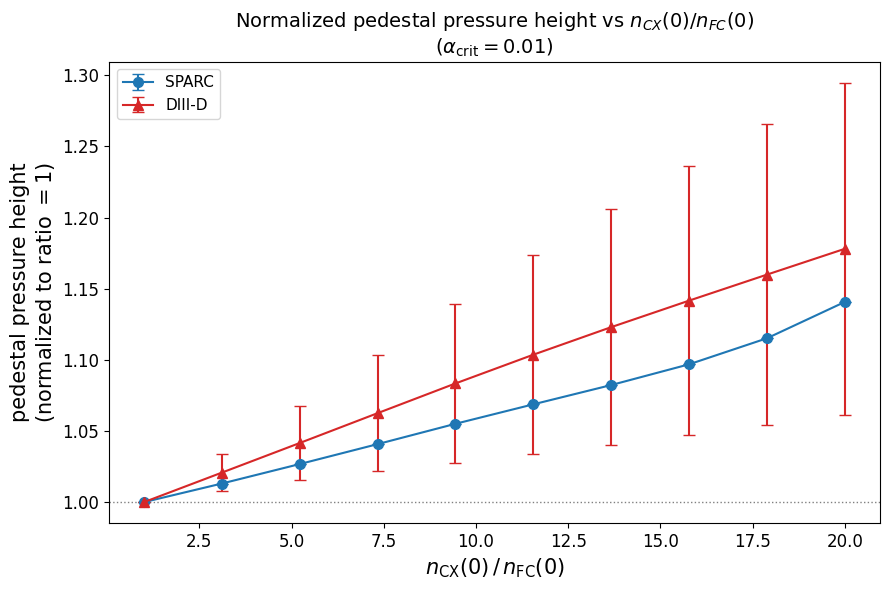

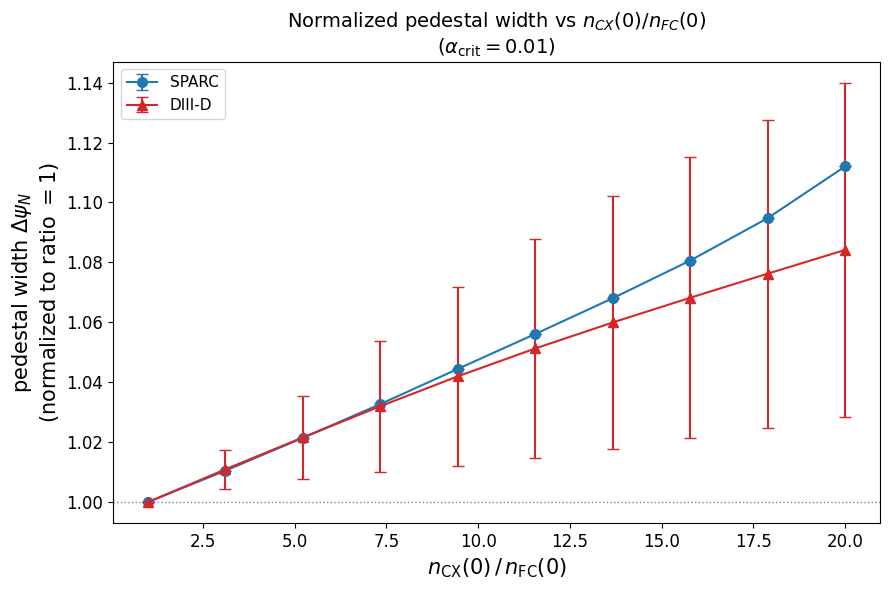

[nFC] alpha_crit = 0.01
  SPARC:
    SPARC_freeparam_loop_nFC: successful 5 at this alpha_crit, failed 10 / pending 0 over all alpha_crit
    5 scan points over 1 equilibria; unnormalized reference height [290.9] kPa, width [0.0328]
  DIII-D:
    125729.03589: successful 8 at this alpha_crit, failed 6 / pending 0 over all alpha_crit
    125730.02445: successful 8 at this alpha_crit, failed 6 / pending 0 over all alpha_crit
    125731.02893: successful 8 at this alpha_crit, failed 6 / pending 0 over all alpha_crit
    125732.03508: successful 9 at this alpha_crit, failed 5 / pending 0 over all alpha_crit
    125761.03760: successful 9 at this alpha_crit, failed 5 / pending 0 over all alpha_crit
    125787.03894: successful 10 at this alpha_crit, failed 4 / pending 0 over all alpha_crit
    128398.04295: successful 10 at this alpha_crit, failed 0 / pending 0 over all alpha_crit
    128413.04088: successful 10 at this alpha_crit, failed 1 / pending 0 over all alpha_crit
    128572.03809: 

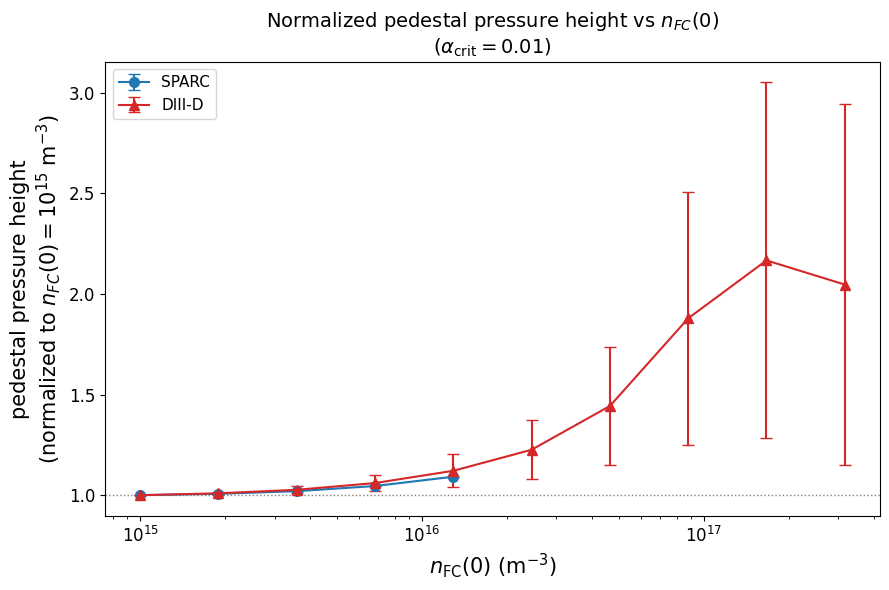

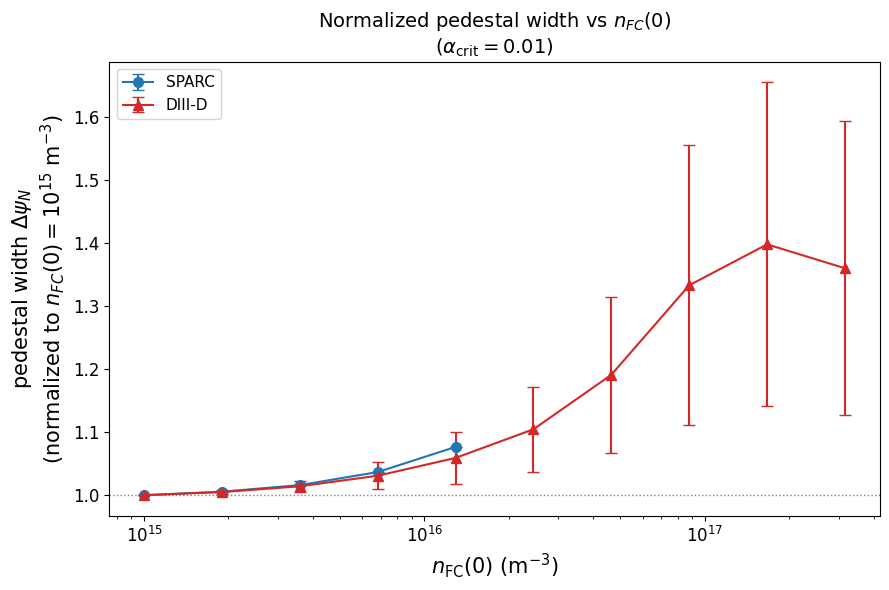

In [2]:
# --- SPARC vs DIII-D: normalized ESCAPE pedestal height and width ---
# One colour per machine. Each equilibrium is divided by its own value at the
# reference point of the scan (ratio = 1 for the nCX scan, nFC(0) = 1e15 for the
# nFC scan) before the equilibria are averaged, so the machines are compared on
# relative response rather than on absolute pedestal size. DIII-D error bars are
# the standard deviation of those normalized curves over its equilibria; SPARC
# has one equilibrium, so its error bars are zero.

for scan_name, spec in SCAN_SPEC.items():
    print(f'[{scan_name}] alpha_crit = {ALPHA_CRIT:g}')
    data = {}
    for device, dirs in SCAN_DIRS.items():
        print(f'  {device}:')
        points, equils_used, raw_refs = scan_points(
            dirs[scan_name], spec['key'], ALPHA_CRIT, spec['ref'])
        if not points:
            continue
        refs_h = ', '.join(f'{r["ped_h"]:.1f}' for r in raw_refs.values())
        refs_w = ', '.join(f'{r["ped_wid"]:.4f}' for r in raw_refs.values())
        print(f'    {len(points)} scan points over {len(equils_used)} equilibria; '
              f'unnormalized reference height [{refs_h}] kPa, width [{refs_w}]')
        data[device] = points

    if not data:
        print('  nothing to plot for this scan')
        continue

    # --- 1. normalized ESCAPE pedestal pressure height ---------------------------
    fig, ax = plt.subplots(figsize=(9, 6))
    for device, pts in data.items():
        c, mk = DEVICE_COLORS[device], DEVICE_MARKERS[device]
        ax.errorbar([p['param'] for p in pts], [p['ped_h'] for p in pts],
                    yerr=[p['ped_h_std'] for p in pts],
                    fmt=f'{mk}-', color=c, markersize=7,
                    ecolor=c, elinewidth=1.5, capsize=4, label=device)

    ax.axhline(1.0, color='grey', linestyle=':', linewidth=1, zorder=0)
    if spec['logx']:
        ax.set_xscale('log')
    ax.set_xlabel(spec['axis_label'], fontsize=15)
    ax.set_ylabel('pedestal pressure height\n'
                  f'(normalized to {spec["ref_label"]})', fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc='best')
    ax.set_title(f'Normalized pedestal pressure height vs {spec["title_label"]}\n'
                 rf'($\alpha_{{\mathrm{{crit}}}}={ALPHA_CRIT:g}$)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- 2. normalized ESCAPE pedestal width -------------------------------------
    fig, ax = plt.subplots(figsize=(9, 6))
    for device, pts in data.items():
        c, mk = DEVICE_COLORS[device], DEVICE_MARKERS[device]
        ax.errorbar([p['param'] for p in pts], [p['ped_wid'] for p in pts],
                    yerr=[p['ped_wid_std'] for p in pts],
                    fmt=f'{mk}-', color=c, markersize=7,
                    ecolor=c, elinewidth=1.5, capsize=4, label=device)

    ax.axhline(1.0, color='grey', linestyle=':', linewidth=1, zorder=0)
    if spec['logx']:
        ax.set_xscale('log')
    ax.set_xlabel(spec['axis_label'], fontsize=15)
    ax.set_ylabel(r'pedestal width $\Delta\psi_N$' + '\n'
                  f'(normalized to {spec["ref_label"]})', fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc='best')
    ax.set_title(f'Normalized pedestal width vs {spec["title_label"]}\n'
                 rf'($\alpha_{{\mathrm{{crit}}}}={ALPHA_CRIT:g}$)', fontsize=14)
    plt.tight_layout()
    plt.show()